In [9]:
import librosa
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, medfilt
from scipy.ndimage import uniform_filter1d
import soundfile as sf
import pywt

from transformers import Resampler, SpectralSubtractor, WaveletDenoiser
from config import SAMPLING_RATE, MAX_DURATION, MIN_DURATION

Flujo objetivo:  

audio_entero -> **segmentador** -> Resampler -> pipeline.predict(X) | .predict_proba(X) -> output binario


# Segmentación de audios completos ($\approx 30$ seg) a ciclos respiratorios

In [ ]:
folder = './audios_propios'

X = []

for file in os.listdir(folder):
    if 'respiracion' in file:
        X.append(os.path.join(folder, file))

X

['./audios_propios\\respiracion1.ogg',
 './audios_propios\\respiracion10.ogg',
 './audios_propios\\respiracion11.ogg',
 './audios_propios\\respiracion2.ogg',
 './audios_propios\\respiracion3.ogg',
 './audios_propios\\respiracion4.ogg',
 './audios_propios\\respiracion5.ogg',
 './audios_propios\\respiracion6.ogg',
 './audios_propios\\respiracion7.ogg',
 './audios_propios\\respiracion8.ogg',
 './audios_propios\\respiracion9.ogg']

La respiración 4 contiene wheeze!!

## Segmentación
Ahora vamos a lo más importante, somos capaces de dividir los audios en ciclos?

### Energy Based

In [3]:
def plot_mel_with_segments(y, sr, segments, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    melspec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    melspec_db = librosa.power_to_db(melspec, ref=np.max)
    img = librosa.display.specshow(
        melspec_db, sr=sr, x_axis='time', y_axis='mel', ax=ax
    )
    for (s, e) in segments:
        ax.axvspan(s, e, color='white', alpha=0.3)

In [ ]:
def filter(y, sr, lowcut=0, highcut=4_000, order=4):
    nyq = 0.5 * sr
    low = lowcut / nyq
    high = highcut / nyq
    if low == 0:
        b, a = butter(order, high, btype='low')
    else:
        b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, y)

def filter_and_resample(path, sr_target=SAMPLING_RATE, lowcut=0, highcut=4_000):
    y, sr = librosa.load(path, sr=None)
    y = filter(y, sr, lowcut=lowcut, highcut=highcut)
    if sr != sr_target:
        y = librosa.resample(y, orig_sr=sr, target_sr=sr_target)
    return y, sr_target

def spectral_subtract(y, sr, n_fft=1024, hop_length=512, win_length=1024, alpha=1.5):
    S = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, win_length=win_length)
    mag, phase = np.abs(S), np.angle(S)

    noise_mag = np.median(mag, axis=1, keepdims=True)

    mag_denoised = mag - alpha * noise_mag
    mag_denoised = np.maximum(mag_denoised, 1e-10)
    S_d = mag_denoised * np.exp(1j * phase)
    y_d = librosa.istft(S_d, hop_length=hop_length, win_length=win_length)
    return y_d, sr

def wavelet_denoise(signal, wavelet='db4', level=4, threshold_method='soft'):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745  # estimación del ruido
    uthresh = sigma * np.sqrt(2 * np.log(len(signal)))
    coeffs_thresh = [coeffs[0]] + [
        pywt.threshold(c, value=uthresh, mode=threshold_method)
        for c in coeffs[1:]
    ]
    return pywt.waverec(coeffs_thresh, wavelet)

def segmentar_energy_based(y, sr, percentile=50, min_event_duration=0.5, alpha=1.5):
    # Reducción de ruido
    y, sr= spectral_subtract(y, sr, alpha=alpha)
    # y = wavelet_denoise(y, level=4, threshold_method='soft')

    # Calcular energía por frame
    rms = librosa.feature.rms(y=y, frame_length=2048, hop_length=512)[0]
    times = librosa.times_like(rms, sr=sr, hop_length=512)

    median = np.median(rms)
    mad = np.median(np.abs(rms - median))  # medida robusta de dispersión
    max_allowed = median + 5 * mad  # o 3–5 según sensibilidad
    rms_clipped = np.clip(rms, None, max_allowed)

    threshold = np.percentile(rms_clipped, percentile)
    active = rms > threshold

    segments = [] # inhalaciones o exhalaciones
    start = None
    for i, val in enumerate(active):
        if val and start is None:
            start = times[i]
        elif not val and start is not None:
            end = times[i]
            if end - start > min_event_duration:
                segments.append((start, end))
            start = None
    
    return segments

def detectar_gaps(segments, dur_audio, gap_threshold=3.0):
    """Detecta gaps sin segmentos."""
    gaps = []
    prev_end = 0
    for start, end in segments:
        if start - prev_end > gap_threshold:
            gaps.append((prev_end, start))
        prev_end = end
    if dur_audio - prev_end > gap_threshold:
        gaps.append((prev_end, dur_audio))
    return gaps

def unir_en_ciclos(segments):
    """Une pares de inhalación/exhalación en ciclos."""
    ciclos = []
    for i in range(0, len(segments), 2):
        if i + 1 < len(segments):
            ciclos.append((segments[i][0], segments[i + 1][1]))
        else:
            ciclos.append(segments[i])
    return ciclos

def refinar_ciclos_largos(ciclos, y, sr, max_cycle_duration=MAX_DURATION, percentile=50, min_event_duration=0.5, alpha=1.5):
    nuevos_ciclos = []

    for start, end in ciclos:
        dur = end - start
        if dur > max_cycle_duration:
            # Re-segmentar el ciclo largo
            y_segment = y[int(start*sr):int(end*sr)]
            sub_segments = segmentar_energy_based(y_segment, sr, percentile=percentile, min_event_duration=min_event_duration, alpha=alpha)
            # Ajustar tiempos al original
            sub_segments = [(s[0]+start, s[1]+start) for s in sub_segments]
            # Volver a unir en ciclos
            sub_ciclos = unir_en_ciclos(sub_segments)
            nuevos_ciclos.extend(sub_ciclos)
        else:
            nuevos_ciclos.append((start, end))

    return nuevos_ciclos

def procesar_audio(path, lowcut=1000, highcut=4000, percentile=50, min_event_duration=0.5, alpha=1.5, alpha_gap=1.5, gap_threshold=3.0, max_cycle_duration=MAX_DURATION, alpha_ciclos=1.5):
    y, sr = librosa.load(path, sr=None)
    y, sr = filter_and_resample(path, lowcut=lowcut, highcut=highcut) #bandpass, no hace falta el resampleo xq eso es parte del pipeline del modelo luego
    dur = len(y)/sr

    # Paso 1: segmentación inicial
    segments = segmentar_energy_based(y, sr, min_event_duration=min_event_duration, percentile=percentile, alpha=alpha)

    # Paso 2: detectar gaps
    gaps = detectar_gaps(segments, dur, gap_threshold=gap_threshold)

    # Paso 3: volver a segmentar los gaps
    for g_start, g_end in gaps:
        y_gap = y[int(g_start*sr):int(g_end*sr)]
        new_segments = segmentar_energy_based(y_gap, sr, min_event_duration=min_event_duration, percentile=percentile, alpha=alpha_gap)
        # Ajustar tiempos al original
        new_segments = [(s[0]+g_start, s[1]+g_start) for s in new_segments]
        segments.extend(new_segments)

    # Ordenar segmentos
    segments.sort(key=lambda x: x[0])

    # Paso 4: unir en ciclos
    ciclos = unir_en_ciclos(segments)

    # Paso 5: refinar ciclos largos
    ciclos = refinar_ciclos_largos(ciclos, y, sr, max_cycle_duration=max_cycle_duration,
                                    percentile=percentile, min_event_duration=min_event_duration, alpha=alpha_ciclos)

    return ciclos


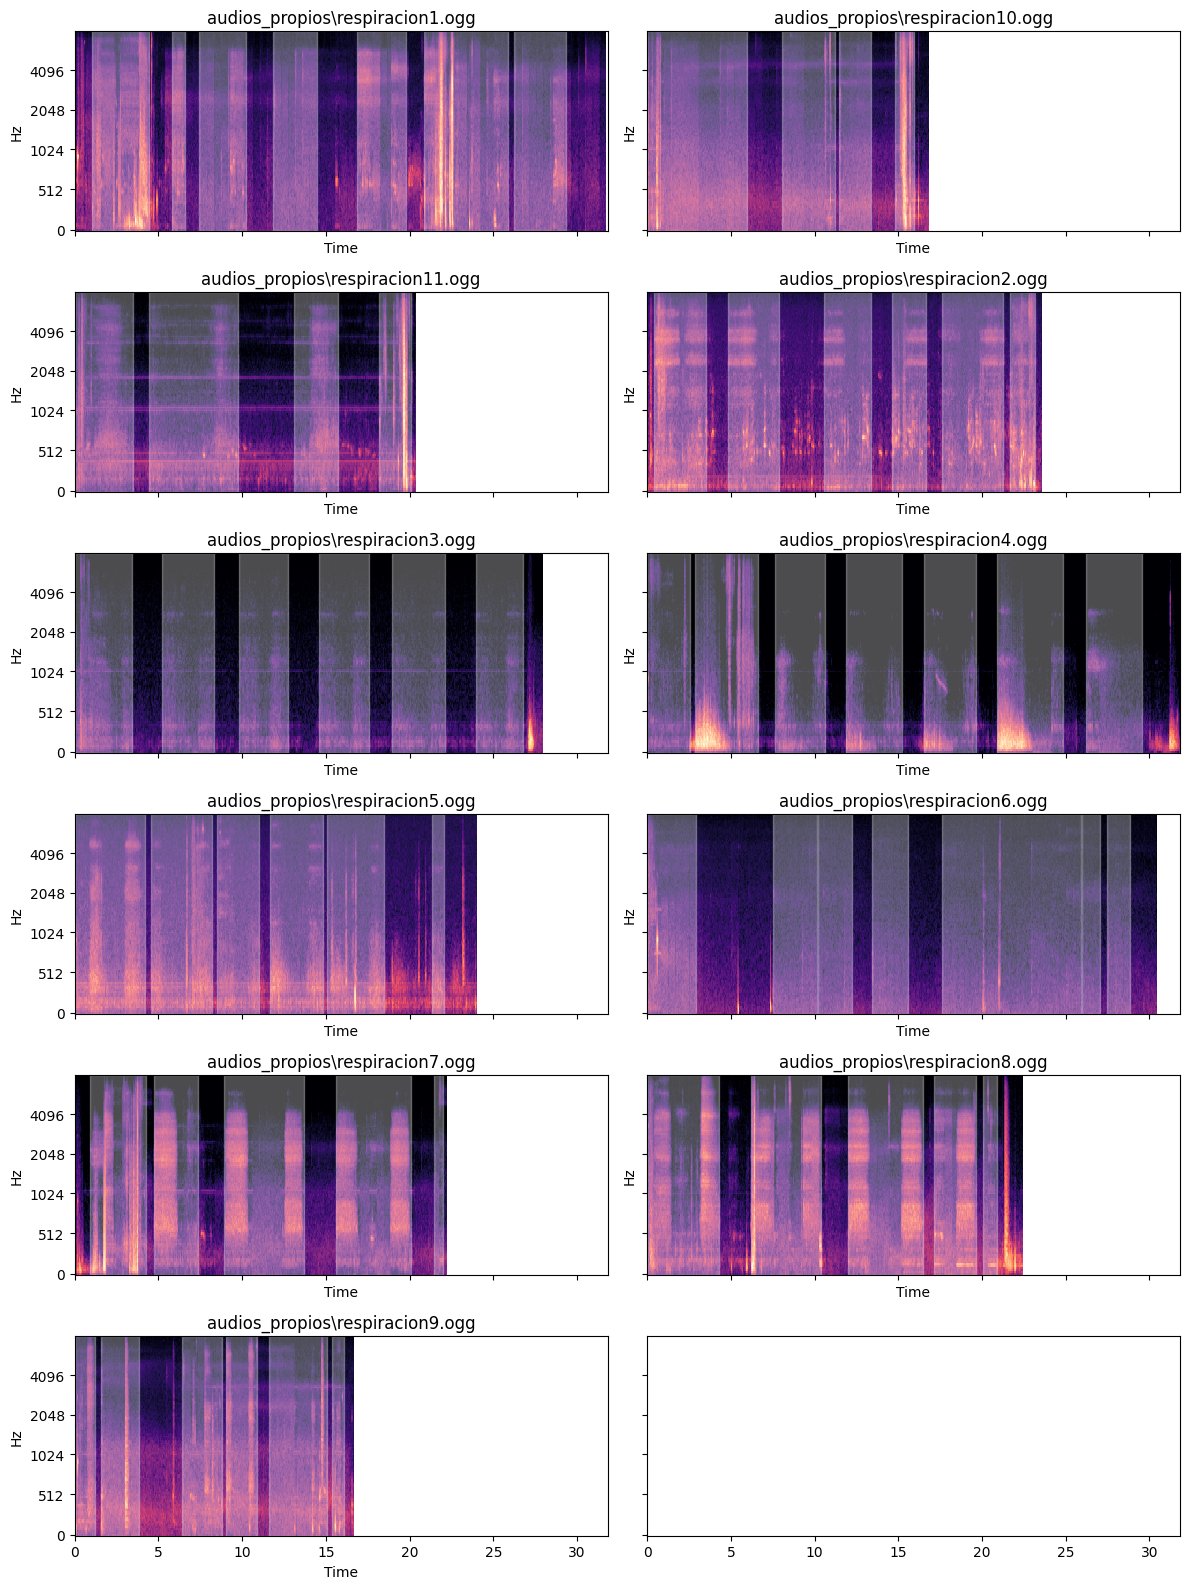

In [ ]:
fig, axes = plt.subplots(6, 2, figsize=(12, 16), sharex=True, sharey=True)

axes = axes.flatten()

for i, path in enumerate(X):
    y, sr = librosa.load(path, sr=SAMPLING_RATE)
    ciclos = procesar_audio(path, lowcut=1000, highcut=4000, percentile=50, min_event_duration=0.5, alpha=1.5,
                            alpha_gap=1.5, gap_threshold=2.0,
                            alpha_ciclos=2) #tambien podria agregar percentile de cliclos y gaps

    plot_mel_with_segments(y, sr, ciclos, ax=axes[i])
    axes[i].set_title(f"{path.split('/')[-1]}")

plt.tight_layout()
plt.show()

La segmentación jamás será perfecta, el modelo debería ser lo suficientemente robusto para poder funcionar de manera casi optima con estos ciclos imperfectos.

Intentar hacer el proceso recursivo (dificil).

Mirar si podemos hacer que el alpha del spectral_substract no use sonidos cortos, porque actualmente los incluye en el calculo.

Puede ser una buena idea asignar un valor que refleje la calidad de la segmentación y usarla para la toma de decisión final. Este valor podría considerar el largo de los segmentos (deberían ser parecidos) y su duración (un cilo anda entre 3 y 5 seg. en promedio). Podría seer un valor por ciclo o por audio.

Guardamos los ciclos

In [ ]:
output_folder = '../audios_propios/ciclos_energy_based'
os.makedirs(output_folder, exist_ok=True)

# guardar ciclos
for path in paths:
    y, sr = librosa.load(path, sr=SAMPLING_RATE)
    ciclos = procesar_audio(path, lowcut=1000, percentile=50, min_event_duration=0.5, alpha=1.5,
                            alpha_gap=1.5, gap_threshold=2.0,
                            max_cycle_duration=6.0, alpha_ciclos=1.5)

    base_name = os.path.basename(path).replace('.ogg', '')
    for i, (start, end) in enumerate(ciclos):
        start_sample = int(start * sr)
        end_sample = int(end * sr)
        ciclo_audio = y[start_sample:end_sample]
        output_path = os.path.join(output_folder, f"{base_name}_ciclo_{i+1}.wav")
        sf.write(output_path, ciclo_audio, sr)

Vamos a ver un mel

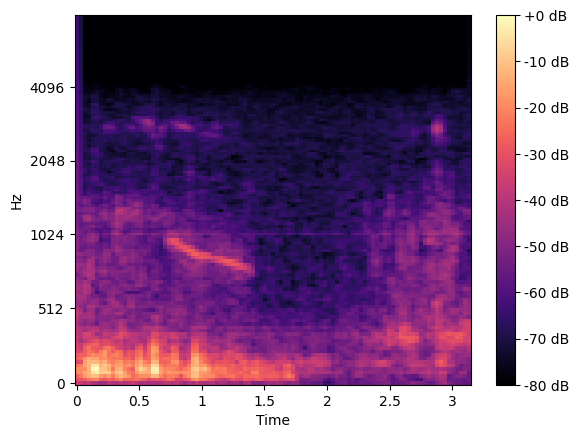

In [30]:
y, sr = filter_and_resample('./audios_propios/ciclos_energy_based/respiracion4_ciclo_5.wav')

# plot melspec
melspec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
melspec_db = librosa.power_to_db(melspec, ref=np.max)
librosa.display.specshow(melspec_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format="%+2.0f dB");

Puede ser que haya que agregar un poco mas de margen para que no termine de manera tan abrupta